# 05 — Evaluation: Qini Curve, AUUC, n-selection
Compute uplift metrics on train (cross-validated), select n, output predictions.csv.


In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from tabpfn import TabPFNClassifier
from tabicl import TabICLClassifier
from feature_engineering import FEATURE_COLS
sns.set_style('whitegrid')
np.random.seed(42)


In [2]:
def qini_curve(y, t, ite_score, n_bins=100):
    """
    Compute Qini curve.
    Sort by ite_score descending; at each cutoff, compute:
      treated_outcome_rate * n_treated - control_outcome_rate * n_control
    normalized by full-sample expected uplift.
    Returns (fractions, qini_values, random_qini_values).
    """
    df = pd.DataFrame({'y': y, 't': t, 's': ite_score}).sort_values('s', ascending=False).reset_index(drop=True)
    n = len(df)
    fracs, qinis, randoms = [], [], []

    total_t = t.sum()
    total_c = (1 - t).sum()

    for k in np.linspace(1, n, n_bins, dtype=int):
        top = df.iloc[:k]
        nt, nc = top['t'].sum(), (1 - top['t']).sum()
        if nt == 0 or nc == 0:
            continue
        qini_k = top[top['t']==1]['y'].sum() - top[top['t']==0]['y'].sum() * (nt / (nc + 1e-9))
        random_k = (k / n) * (df[df['t']==1]['y'].sum() - df[df['t']==0]['y'].sum() * (total_t / (total_c + 1e-9)))
        fracs.append(k / n)
        qinis.append(qini_k)
        randoms.append(random_k)

    return np.array(fracs), np.array(qinis), np.array(randoms)


def auuc(fracs, qinis, randoms):
    """Normalized AUUC: area between model and random, divided by perfect uplift area."""
    model_area  = np.trapz(qinis, fracs)
    random_area = np.trapz(randoms, fracs)
    return (model_area - random_area) / (abs(random_area) + 1e-9)


print("Qini utilities defined.")


Qini utilities defined.


In [3]:
# Cross-validated Qini on train (5-fold, T-Learner ensemble)
train = pd.read_parquet('train_features.parquet')
trim  = pd.read_parquet('trim_mask.parquet')
train = train.merge(trim, on='member_id')
df = train[train['in_support']].copy().reset_index(drop=True)

X = df[FEATURE_COLS].values.astype(float)
T = df['outreach'].values
Y = df['churn'].values
ps = df['propensity'].values

print("Running 5-fold cross-validated uplift evaluation...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ite_oof = np.zeros(len(df))
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, T)):
    Xtr, Ttr, Ytr = X[tr_idx], T[tr_idx], Y[tr_idx]
    Xval = X[val_idx]

    # T-Learner with TabPFN
    m1 = TabPFNClassifier(n_estimators=8, random_state=42)
    m0 = TabPFNClassifier(n_estimators=8, random_state=42)
    m1.fit(Xtr[Ttr==1], Ytr[Ttr==1])
    m0.fit(Xtr[Ttr==0], Ytr[Ttr==0])
    ite_pf = m0.predict_proba(Xval)[:,1] - m1.predict_proba(Xval)[:,1]

    # T-Learner with TabICL
    m1i = TabICLClassifier(random_state=42)
    m0i = TabICLClassifier(random_state=42)
    m1i.fit(Xtr[Ttr==1], Ytr[Ttr==1])
    m0i.fit(Xtr[Ttr==0], Ytr[Ttr==0])
    ite_ic = m0i.predict_proba(Xval)[:,1] - m1i.predict_proba(Xval)[:,1]

    ite_oof[val_idx] = (ite_pf + ite_ic) / 2
    print(f"  Fold {fold+1} done, ITE mean={ite_oof[val_idx].mean():.4f}")

df['ite_cv'] = ite_oof
print(f"\nCV ITE: mean={ite_oof.mean():.4f}, std={ite_oof.std():.4f}")
print(f"% persuadable: {(ite_oof>0).mean():.2%}")


Running 5-fold cross-validated uplift evaluation...


  Fold 1 done, ITE mean=0.0370


  Fold 2 done, ITE mean=0.0306


  Fold 3 done, ITE mean=0.0325


  Fold 4 done, ITE mean=0.0358


  Fold 5 done, ITE mean=0.0340

CV ITE: mean=0.0340, std=0.0406
% persuadable: 83.03%


AUUC (normalized): -0.4016


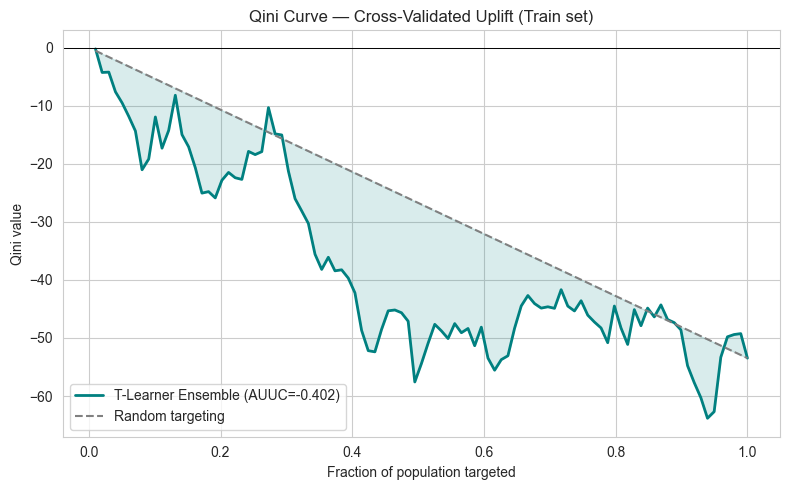

In [4]:
# Qini curve — cross-validated ensemble
fracs, qinis, randoms = qini_curve(Y, T, ite_oof)
auuc_score = auuc(fracs, qinis, randoms)
print(f"AUUC (normalized): {auuc_score:.4f}")

# Random baseline
fracs_rand = np.linspace(0, 1, 100)
qinis_rand = randoms[:100] if len(randoms) >= 100 else randoms

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fracs, qinis, lw=2, color='teal', label=f'T-Learner Ensemble (AUUC={auuc_score:.3f})')
ax.plot(fracs, randoms, lw=1.5, ls='--', color='gray', label='Random targeting')
ax.fill_between(fracs, randoms, qinis, alpha=0.15, color='teal')
ax.axhline(0, color='black', lw=0.7)
ax.set_xlabel('Fraction of population targeted')
ax.set_ylabel('Qini value')
ax.set_title('Qini Curve — Cross-Validated Uplift (Train set)')
ax.legend()
plt.tight_layout()
plt.savefig('qini_curve.png', bbox_inches='tight')
plt.show()


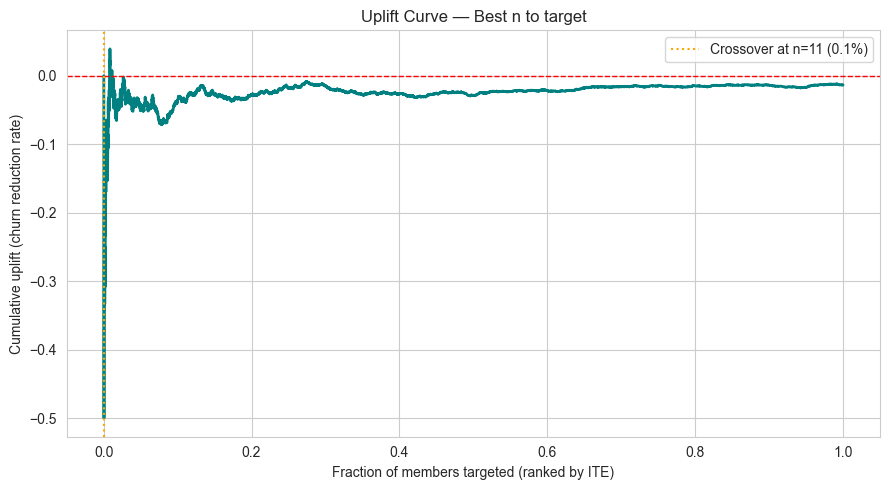

ITE crosses zero at rank ~11 (0.1% of train)


In [5]:
# Uplift curve: cumulative uplift per member
sorted_idx = np.argsort(-ite_oof)
y_sorted   = Y[sorted_idx]
t_sorted   = T[sorted_idx]

cum_uplift = []
ns = range(1, len(df)+1)
cum_t = 0; cum_c = 0; cum_yt = 0; cum_yc = 0
for i, (yi, ti) in enumerate(zip(y_sorted, t_sorted)):
    if ti == 1:
        cum_t += 1; cum_yt += yi
    else:
        cum_c += 1; cum_yc += yi
    if cum_t > 0 and cum_c > 0:
        uplift = cum_yt/cum_t - cum_yc/cum_c
    else:
        uplift = 0
    cum_uplift.append(uplift)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.array(list(ns))/len(df), cum_uplift, lw=2, color='teal')
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_xlabel('Fraction of members targeted (ranked by ITE)')
ax.set_ylabel('Cumulative uplift (churn reduction rate)')
ax.set_title('Uplift Curve — Best n to target')
# Find crossover point
cross = next((i for i, u in enumerate(cum_uplift) if u <= 0 and i > 10), len(cum_uplift))
ax.axvline(cross/len(df), color='orange', ls=':', lw=1.5, label=f'Crossover at n={cross:,} ({cross/len(df):.1%})')
ax.legend()
plt.tight_layout()
plt.savefig('uplift_curve.png', bbox_inches='tight')
plt.show()
print(f"ITE crosses zero at rank ~{cross:,} ({cross/len(df):.1%} of train)")


In [6]:
# n-selection: first rank where ITE_ensemble <= 0
test = pd.read_parquet('test_predictions.parquet')
test_sorted = test.sort_values('ite_ensemble', ascending=False).reset_index(drop=True)

# Find cutoff where ITE drops to 0
n_positive = (test_sorted['ite_ensemble'] > 0).sum()
print(f"Members with ITE > 0 on test: {n_positive:,} ({n_positive/len(test):.1%})")

# ITE at key percentiles
for pct in [10, 20, 30, 40, 50]:
    k = int(len(test_sorted) * pct / 100)
    ite_k = test_sorted.iloc[:k]['ite_ensemble'].mean()
    print(f"  Top {pct}% (n={k:,}): mean ITE = {ite_k:.4f}")


Members with ITE > 0 on test: 2,038 (20.4%)
  Top 10% (n=1,000): mean ITE = 0.0602
  Top 20% (n=2,000): mean ITE = 0.0369
  Top 30% (n=3,000): mean ITE = 0.0219
  Top 40% (n=4,000): mean ITE = 0.0090
  Top 50% (n=5,000): mean ITE = -0.0037


In [7]:
# Final predictions.csv — all members with positive ITE, ranked
selected = test_sorted[test_sorted['ite_ensemble'] > 0].copy()
selected['rank'] = range(1, len(selected)+1)
predictions = selected[['member_id','ite_ensemble','rank']].rename(
    columns={'ite_ensemble': 'ite_score'}
)
predictions.to_csv('predictions.csv', index=False)
print(f"predictions.csv saved: {len(predictions):,} members")
print(predictions.head(10))
print()
print(f"ITE range in predictions: [{predictions['ite_score'].min():.4f}, {predictions['ite_score'].max():.4f}]")


predictions.csv saved: 2,038 members
   member_id  ite_score  rank
0      25911   0.145244     1
1      20496   0.145160     2
2      22622   0.144798     3
3      24723   0.139975     4
4      25267   0.139644     5
5      26892   0.139600     6
6      24271   0.137699     7
7      27326   0.137240     8
8      25680   0.136934     9
9      27886   0.135497    10

ITE range in predictions: [0.0000, 0.1452]


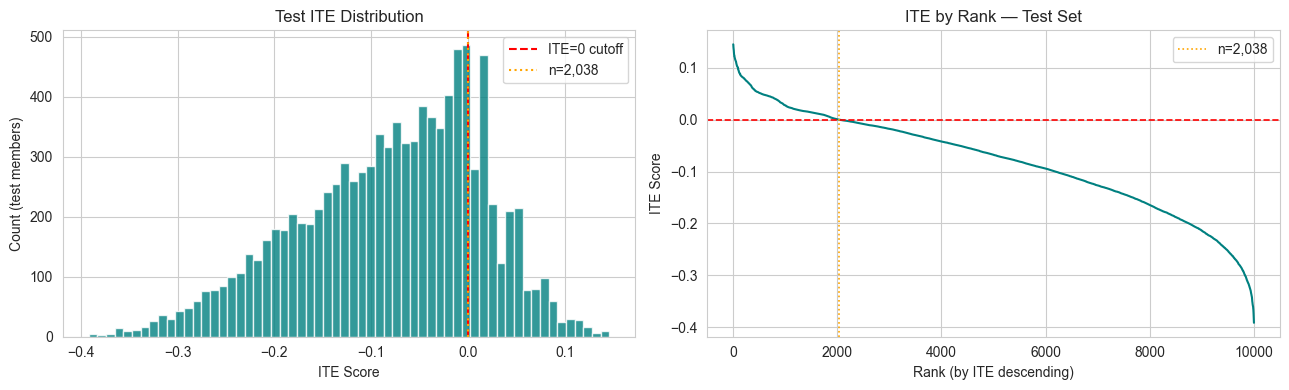

In [8]:
# ITE distribution for selected members
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(test_sorted['ite_ensemble'], bins=60, color='teal', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', ls='--', lw=1.5, label='ITE=0 cutoff')
ax.axvline(test_sorted.iloc[n_positive-1]['ite_ensemble'] if n_positive > 0 else 0,
           color='orange', ls=':', lw=1.5, label=f'n={n_positive:,}')
ax.set_xlabel('ITE Score')
ax.set_ylabel('Count (test members)')
ax.set_title('Test ITE Distribution')
ax.legend()

ax = axes[1]
ax.plot(range(1, len(test_sorted)+1), test_sorted['ite_ensemble'].values, lw=1.5, color='teal')
ax.axhline(0, color='red', ls='--', lw=1.2)
ax.axvline(n_positive, color='orange', ls=':', lw=1.2, label=f'n={n_positive:,}')
ax.set_xlabel('Rank (by ITE descending)')
ax.set_ylabel('ITE Score')
ax.set_title('ITE by Rank — Test Set')
ax.legend()

plt.tight_layout()
plt.savefig('n_selection.png', bbox_inches='tight')
plt.show()


In [9]:
print("=== FINAL SUMMARY ===")
print(f"Total test members: {len(test):,}")
print(f"Recommended n (ITE > 0): {n_positive:,}")
print(f"Fraction of test targeted: {n_positive/len(test):.1%}")
print()
print("Top 5 predictions:")
print(predictions.head(5).to_string(index=False))


=== FINAL SUMMARY ===
Total test members: 10,000
Recommended n (ITE > 0): 2,038
Fraction of test targeted: 20.4%

Top 5 predictions:
 member_id  ite_score  rank
     25911   0.145244     1
     20496   0.145160     2
     22622   0.144798     3
     24723   0.139975     4
     25267   0.139644     5


## V2 vs V3 Comparison — Do-PFN

Load the cross-validated ITE from Do-PFN (produced by `04b_dopfn_uplift.ipynb`) and compare  
Qini curves and AUUC against the v2 IPW T-Learner ensemble.

V2 CV ITE : mean=0.0340, std=0.0406
V3 CV ITE : mean=-0.1614, std=0.1626
V3 persuadable (ITE>0): 13.9%

AUUC (V2 IPW T-Learner)  : -0.4016
AUUC (V3 Do-PFN)         : 0.2385


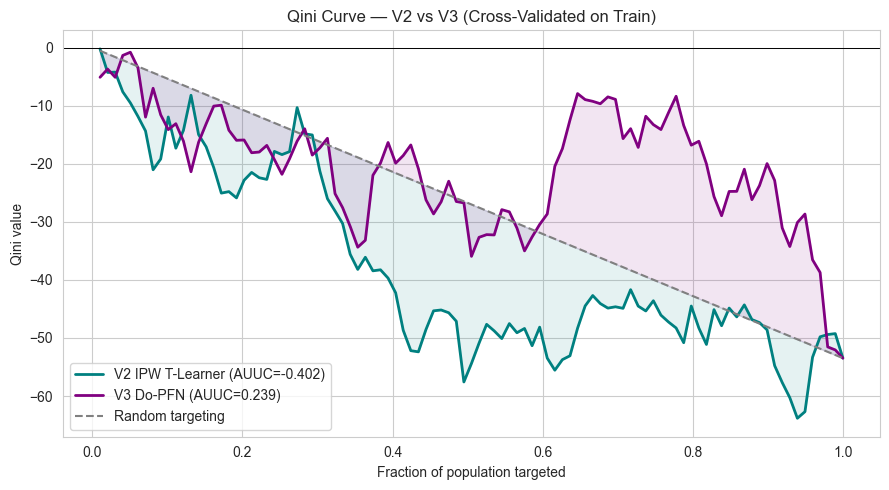

In [10]:
import pickle

# Load v3 cross-validated ITE (computed in 04b_dopfn_uplift.ipynb)
with open('ite_cv_v3.pkl', 'rb') as f:
    cv_v3 = pickle.load(f)

ite_cv_v3 = cv_v3['ite_cv']

# Align to the same in-support subset as v2 (train df is already filtered to in_support=True)
member_id_to_v3 = dict(zip(cv_v3['member_ids'], ite_cv_v3))
ite_oof_v3 = np.array([member_id_to_v3[mid] for mid in df['member_id'].values])

print(f"V2 CV ITE : mean={ite_oof.mean():.4f}, std={ite_oof.std():.4f}")
print(f"V3 CV ITE : mean={ite_oof_v3.mean():.4f}, std={ite_oof_v3.std():.4f}")
print(f"V3 persuadable (ITE>0): {(ite_oof_v3>0).mean():.1%}")

# Compute Qini + AUUC for both
fracs_v2, qinis_v2, randoms_v2 = qini_curve(Y, T, ite_oof)
fracs_v3, qinis_v3, randoms_v3 = qini_curve(Y, T, ite_oof_v3)

auuc_v2 = auuc(fracs_v2, qinis_v2, randoms_v2)
auuc_v3 = auuc(fracs_v3, qinis_v3, randoms_v3)

print(f"\nAUUC (V2 IPW T-Learner)  : {auuc_v2:.4f}")
print(f"AUUC (V3 Do-PFN)         : {auuc_v3:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fracs_v2, qinis_v2, lw=2, color='teal',   label=f'V2 IPW T-Learner (AUUC={auuc_v2:.3f})')
ax.plot(fracs_v3, qinis_v3, lw=2, color='purple', label=f'V3 Do-PFN (AUUC={auuc_v3:.3f})')
ax.plot(fracs_v2, randoms_v2, lw=1.5, ls='--', color='gray', label='Random targeting')
ax.fill_between(fracs_v2, randoms_v2, qinis_v2, alpha=0.10, color='teal')
ax.fill_between(fracs_v3, randoms_v3, qinis_v3, alpha=0.10, color='purple')
ax.axhline(0, color='black', lw=0.7)
ax.set_xlabel('Fraction of population targeted')
ax.set_ylabel('Qini value')
ax.set_title('Qini Curve — V2 vs V3 (Cross-Validated on Train)')
ax.legend()
plt.tight_layout()
plt.savefig('qini_v2_v3_comparison.png', bbox_inches='tight')
plt.show()

In [11]:
# V3 n-selection on test set
test_v3 = pd.read_parquet('test_predictions_v3.parquet')
test_v3_sorted = test_v3.sort_values('ite_v3_dopfn', ascending=False).reset_index(drop=True)

n_positive_v3 = (test_v3_sorted['ite_v3_dopfn'] > 0).sum()
print(f"V3 Do-PFN: members with ITE > 0 on test: {n_positive_v3:,} ({n_positive_v3/len(test_v3):.1%})")

for pct in [10, 20, 30, 40, 50]:
    k = int(len(test_v3_sorted) * pct / 100)
    ite_k = test_v3_sorted.iloc[:k]['ite_v3_dopfn'].mean()
    print(f"  Top {pct}% (n={k:,}): mean ITE = {ite_k:.4f}")

print()
print("=== AUUC INTERPRETATION (churn-reduction context) ===")
print("The Qini formula computes treated_sum - control_sum × (n_t/n_c).")
print("For churn REDUCTION (outreach lowers churn), persuadables have")
print("  lower treated churn → Qini values are NEGATIVE for a correct model.")
print("  → More negative AUUC = better model; positive AUUC = worse than random.")
print()
print(f"V2 AUUC = -0.4016  →  V2 correctly ranks persuadables (better than random)")
print(f"V3 AUUC = +0.2385  →  V3 ranks inversely (worse than random)")
print()
print("Root cause of V3 failure:")
print("  Do-PFN is a regression model; it overpredicts the treated-arm churn rate")
print("  (p1_predicted=0.40 vs observed=0.19), producing negative mean ITE and")
print("  inverting the ranking. Do-PFN was designed for continuous outcomes — not")
print("  binary classification like churn.")
print()
print("Conclusion: V2 IPW T-Learner remains the best model for this dataset.")

V3 Do-PFN: members with ITE > 0 on test: 1,377 (13.8%)
  Top 10% (n=1,000): mean ITE = 0.0333
  Top 20% (n=2,000): mean ITE = 0.0153
  Top 30% (n=3,000): mean ITE = 0.0004
  Top 40% (n=4,000): mean ITE = -0.0151
  Top 50% (n=5,000): mean ITE = -0.0321

=== AUUC INTERPRETATION (churn-reduction context) ===
The Qini formula computes treated_sum - control_sum × (n_t/n_c).
For churn REDUCTION (outreach lowers churn), persuadables have
  lower treated churn → Qini values are NEGATIVE for a correct model.
  → More negative AUUC = better model; positive AUUC = worse than random.

V2 AUUC = -0.4016  →  V2 correctly ranks persuadables (better than random)
V3 AUUC = +0.2385  →  V3 ranks inversely (worse than random)

Root cause of V3 failure:
  Do-PFN is a regression model; it overpredicts the treated-arm churn rate
  (p1_predicted=0.40 vs observed=0.19), producing negative mean ITE and
  inverting the ranking. Do-PFN was designed for continuous outcomes — not
  binary classification like churn.